<font color = green >

## Home Task

</font>

Apply various clustering algorithms 

- Agglomerative clustering using `complete` linkage 
- Agglomerative clustering using `single` linkage 
- DBSCAN
- Use albow method to determine the best k for Kmeans


<font color = green >

###  Data 

</font>



In [1]:
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt
import numpy as np

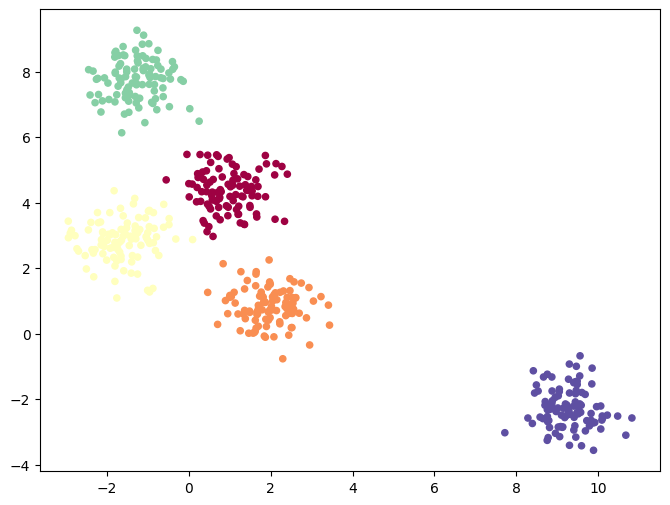

In [2]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, cluster_std = 0.6, random_state = 0)

def plot_blobs(X, y, centroids = None):
        colors = np.array([plt.cm.Spectral(val) for val in np.linspace(0, 1, len(set(y)))])
        plt.figure(figsize=(8,6))
        plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20) 
        if centroids is not None:
            plt.scatter(centroids[:,0], centroids[:,1], c='black', s=50, marker='X')
        plt.show()

plot_blobs(X, y)

<font color="green">

## Solutions

</font>


In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

## Agglomerative Clustering - Complete Linkage

In [4]:
def aglomerative_clustering(X, n_clusters=None, linkage=None):
    # write a funnc for aglomerative clustering with scaling the data before clustering
    model = make_pipeline(StandardScaler(), # scale the data before clustering are recommended for clustering
                          AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage))
    
    y_pred = model.fit_predict(X)
    silhouette_metric = silhouette_score(X, y_pred) # saw in sklearn documentation that silhouette_score is a good metric for clustering
    print(f"Silhouette score: {silhouette_metric}")
    return y_pred, silhouette_metric

predict, metric = aglomerative_clustering(X, n_clusters=5, linkage='complete')

Silhouette score: 0.7158419658070393


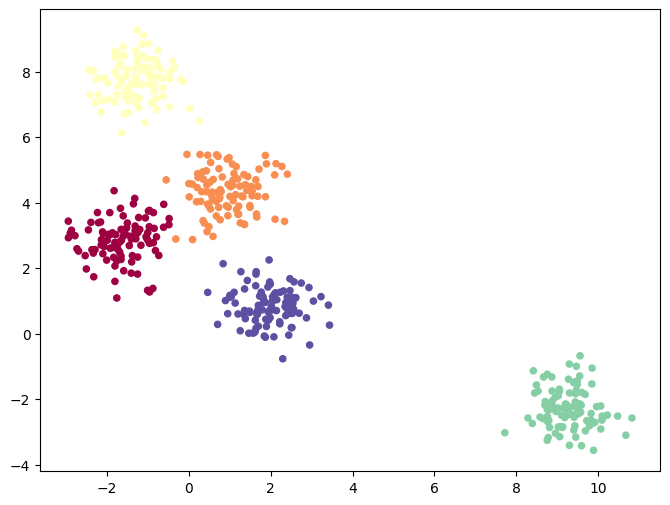

In [5]:
plot_blobs(X, predict)

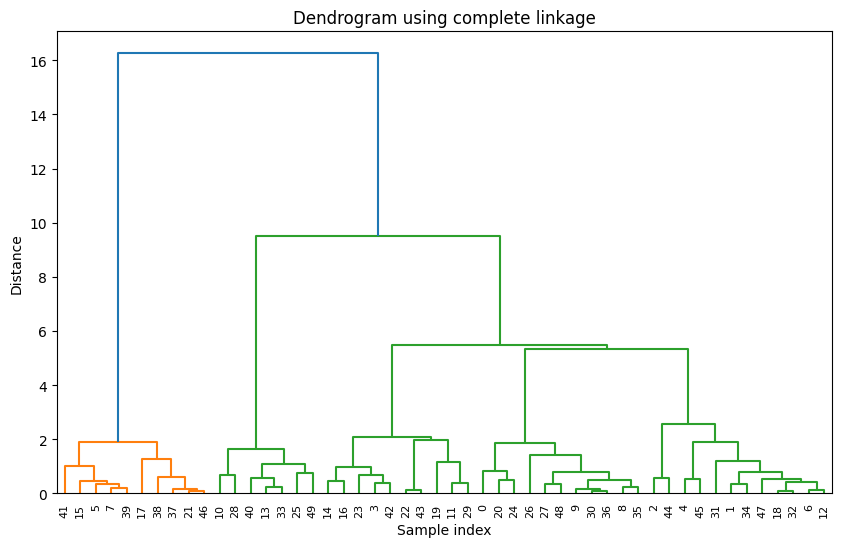

In [6]:
def plot_dendrogram(X, method: str = None):
    plt.figure(figsize=(10, 6))

    linked = linkage(X, method=method)
    dendrogram(linked)
    plt.title(f"Dendrogram using {method} linkage")
    plt.xlabel("Sample index")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(X[:50], method='complete') 

<font color="green">

### 2. Agglomerative Clustering — Single Linkage

</font>

**Single linkage** = distance between two clusters is the **minimum** distance between any
pair of points. Tends to produce elongated, chained clusters. Sensitive to noise.


Silhouette score: 0.5740226624379556


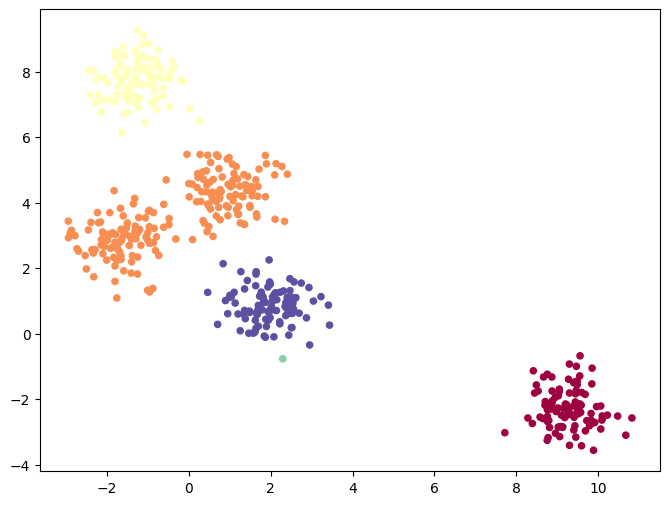

In [7]:
predict, metric = aglomerative_clustering(X, n_clusters=5, linkage='single')
plot_blobs(X, predict)

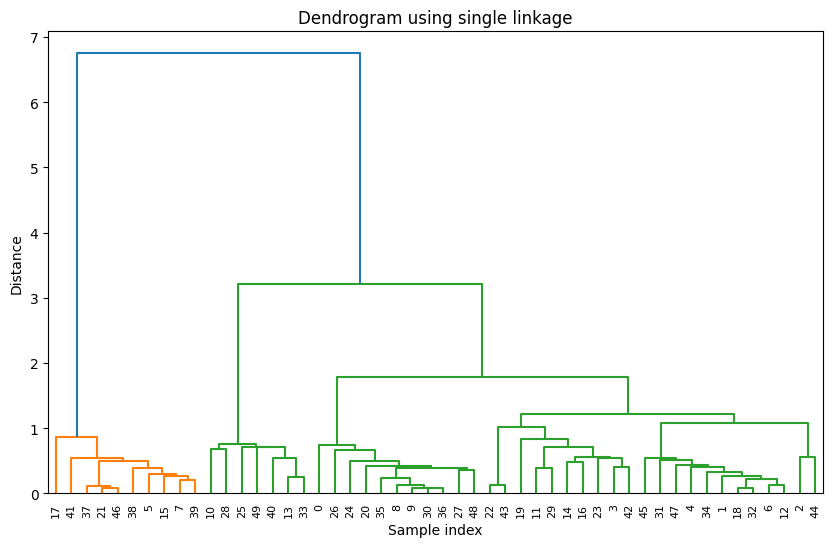

In [8]:
plot_dendrogram(X[:50], method='single')

## DBSCAN

Clusters: 7, Noise points: 23
Silhouette score: 0.553


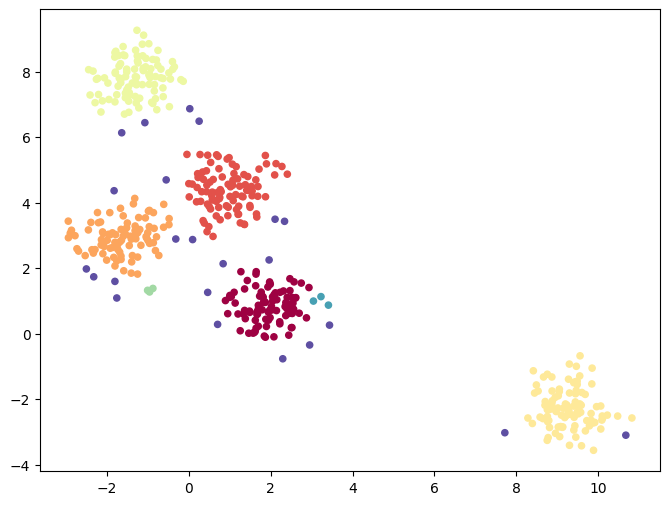

In [9]:
def dbscan_clustering(X, eps=0.1, min_samples=3):
    model = make_pipeline(StandardScaler(), DBSCAN(eps=eps, min_samples=min_samples))
    y_pred = model.fit_predict(X)
    
    n_clusters = len(np.unique(y_pred)) - (1 if -1 in y_pred else 0)
    print(f"Clusters: {n_clusters}, Noise points: {np.sum(y_pred == -1)}")
    
    # remap noise (-1) to its own cluster index so plot_blobs doesn't break
    y_pred[y_pred == -1] = n_clusters
    score = silhouette_score(X, y_pred)
    print(f"Silhouette score: {score:.3f}")
    
    return y_pred, score

predict, metric = dbscan_clustering(X, eps=0.1, min_samples=3)
plot_blobs(X, predict)
plt.show()

## Elbow Method - Best K for K-Means

k=1, Distortion=1000.00
k=2, Distortion=301.00
k=3, Distortion=121.53
k=4, Distortion=56.11
k=5, Distortion=25.64
k=6, Distortion=23.53
k=7, Distortion=21.36
k=8, Distortion=19.99
k=9, Distortion=17.93
k=10, Distortion=15.90


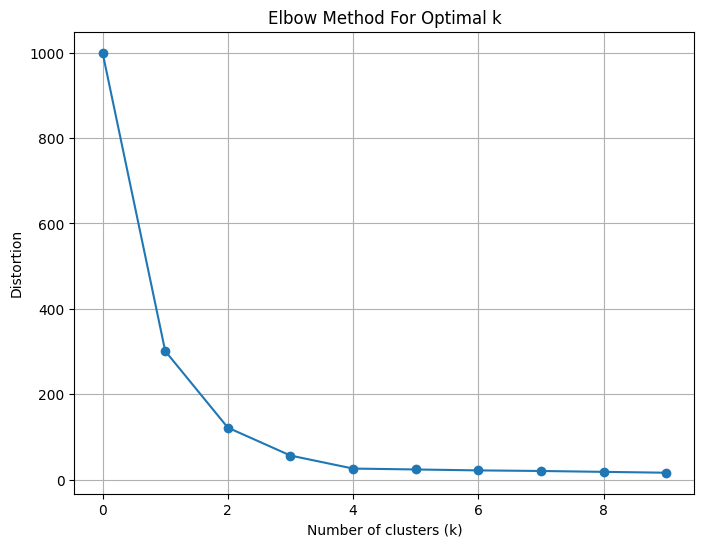

In [10]:
distortions = []
for k in range(1, 11):
    model = make_pipeline(StandardScaler(), KMeans(n_clusters=k, random_state=0, n_init='auto'))
    model.fit(X)
    distortions.append(model.named_steps['kmeans'].inertia_)
    print(f"k={k}, Distortion={distortions[-1]:.2f}")
    
plt.figure(figsize=(8, 6))
plt.plot(distortions, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Distortion')
plt.grid()
plt.show()

k = 5

KMeans Silhouette Score: 0.717


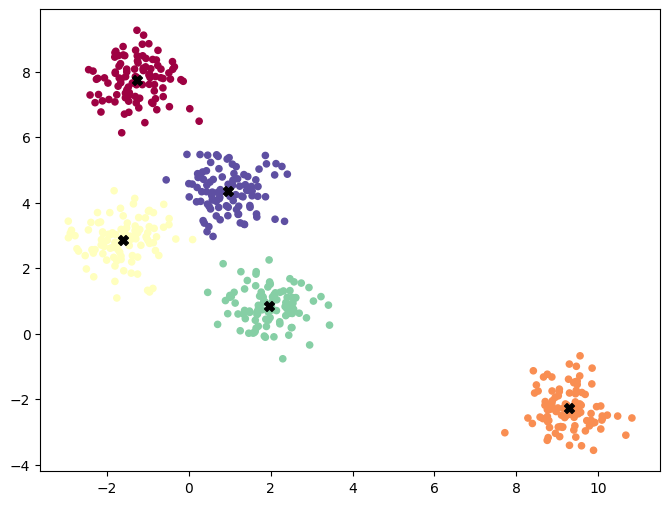

In [11]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init='auto')
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_
metric = silhouette_score(X, labels)
print(f"KMeans Silhouette Score: {metric:.3f}")

plot_blobs(X, labels, centroids=centers)